In [3]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# # Get original colormap
# base_cmap = plt.cm.get_cmap('gist_ncar')

# # Sample it
# colors = base_cmap(np.linspace(0, 1, 256))

# # 🔧 Modify low intensities (first ~15%)
# n_low = int(0.11 * 256)

# for i in range(n_low):
#     t = i / (n_low - 1)  # 0 → 1

#     # Take original color at boundary and scale it down
#     ref_color = colors[n_low].copy()

#     colors[i, :3] = t * ref_color[:3]   # scale RGB only
#     colors[i, 3] = 1.0                  # keep alpha

# custom_cmap = ListedColormap(colors)

base_cmap = plt.cm.get_cmap('gist_ncar')

# Sample it
colors = base_cmap(np.linspace(0, 1, 256))

# 🔧 Modify low intensities (first ~11%): fade down to black
n_low = int(0.11 * 256)

for i in range(n_low):
    t = i / (n_low - 1)  # 0 → 1

    # Take original color at boundary and scale it down
    ref_color = colors[n_low].copy()

    colors[i, :3] = t * ref_color[:3]   # scale RGB only
    colors[i, 3] = 1.0                  # keep alpha

# 🔧 Modify high intensities (top ~20%): fade from magenta up to white
n_high = int(0.20 * 256)
start = 256 - n_high

# magenta reference = the color just below the top band
ref_high = colors[start - 1].copy()

for k in range(n_high):
    i = start + k
    t = k / (n_high - 1)  # 0 → 1
    colors[i, :3] = (1 - t) * ref_high[:3] + t * 1.0   # magenta → white
    colors[i, 3] = 1.0

custom_cmap = ListedColormap(colors)


/tmp/ipykernel_9798/132322448.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap('gist_ncar')


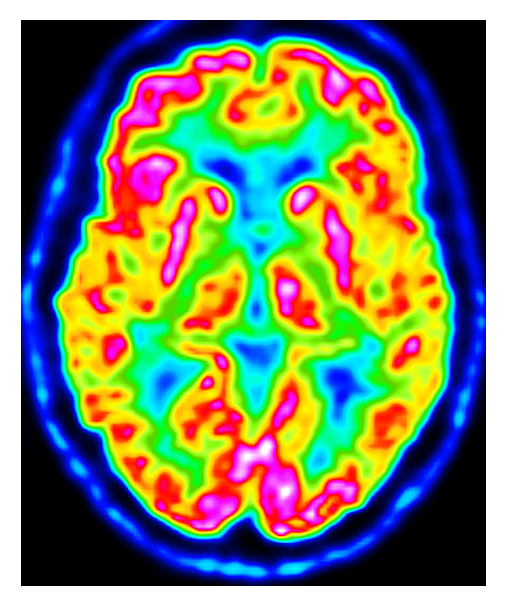

In [4]:
# Load NIfTI file
img = nib.load("shoot/HC/8007703562/20211104/wr_petsuv.nii")
data = img.get_fdata()

slice_axial = data[:, :, 50]

# Rotate for correct orientation (optional but common)
slice_axial = np.rot90(slice_axial)

# Plot with rainbow LUT
plt.figure(figsize=(5, 5), dpi=150)
plt.imshow(slice_axial, cmap=custom_cmap,vmin=0, vmax=11, interpolation="bilinear")
plt.axis('off')
plt.savefig('shoot/overlay/pet.png',
            bbox_inches='tight',
            pad_inches=0,
            transparent=True)
plt.show()

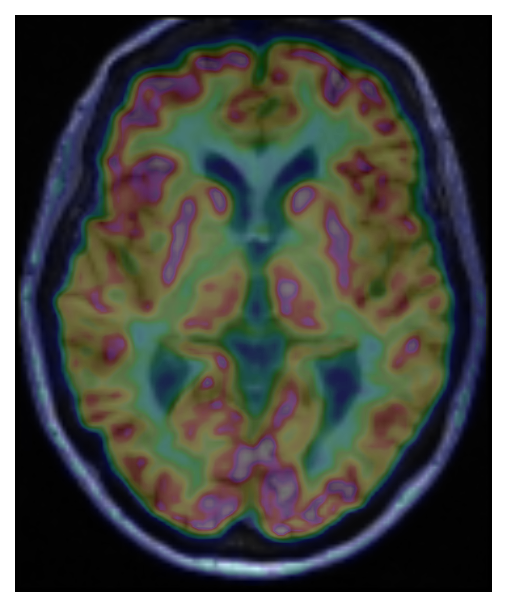

In [16]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# Load images
pet = nib.load("shoot/HC/8007703562/20211104/wr_petsuv.nii")
pet_data = pet.get_fdata()

mri = nib.load("shoot/HC/8007703562/20211104/wmri.nii")
mri_data = mri.get_fdata()

# Choose slice
z = 50
pet_slice = np.rot90(pet_data[:, :, z])
mri_slice = np.rot90(mri_data[:, :, z])

# Plot
plt.figure(figsize=(5, 5), dpi=150)

# MRI background (grayscale)
plt.imshow(mri_slice, cmap='gray', interpolation='bilinear')

# PET overlay (rainbow)
plt.imshow(
    pet_slice,
    cmap=custom_cmap,   # your rainbow LUT
    vmin=0,
    vmax=11,
    alpha=0.2,          # transparency
    interpolation='bilinear'
)

plt.axis('off')
plt.savefig('shoot/overlay/petmri.png',
            bbox_inches='tight',
            pad_inches=0,
            transparent=True)
plt.show()

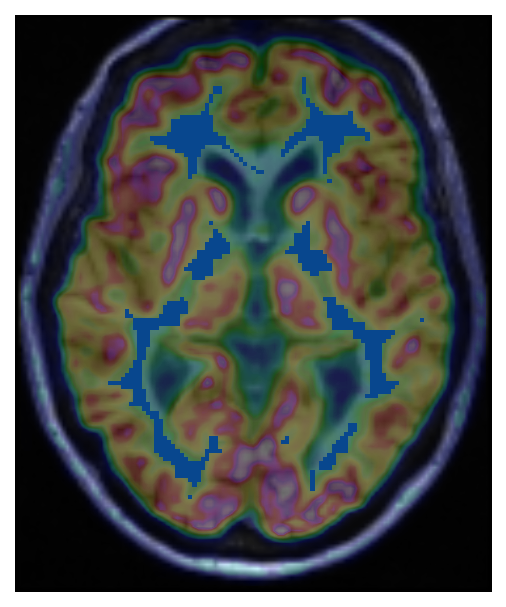

In [17]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# Load images
pet = nib.load("shoot/HC/8007703562/20211104/wr_petsuv.nii")
pet_data = pet.get_fdata()

mri = nib.load("shoot/HC/8007703562/20211104/wmri.nii")
mri_data = mri.get_fdata()

mask = nib.load("shoot/HC/8007703562/20211104/mri/wm_mask_eroded.nii")
mask_data = mask.get_fdata()

# Choose slice
z = 50
pet_slice = np.rot90(pet_data[:, :, z])
mri_slice = np.rot90(mri_data[:, :, z])
mask_slice = np.rot90(mask_data[:, :, z])

# Mask: hide zeros
mask_overlay = np.ma.masked_where(mask_slice == 0, mask_slice)

# Plot
plt.figure(figsize=(5, 5), dpi=150)

# MRI background
plt.imshow(mri_slice, cmap='gray', interpolation='bilinear')

# PET overlay
plt.imshow(
    pet_slice,
    cmap=custom_cmap,
    vmin=0,
    vmax=11,
    alpha=0.2,
    interpolation='bilinear'
)

# 🔴 Mask overlay (red, only where = 1)
plt.imshow(
    mask_overlay,
    cmap='Blues',
    alpha=1.0,
    vmin=0.995,
    vmax=1.0005  # keep mask crisp
)

plt.axis('off')
plt.savefig('shoot/overlay/petmrimask.png',
            bbox_inches='tight',
            pad_inches=0,
            transparent=True)
plt.show()

/tmp/ipykernel_21261/1639109352.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


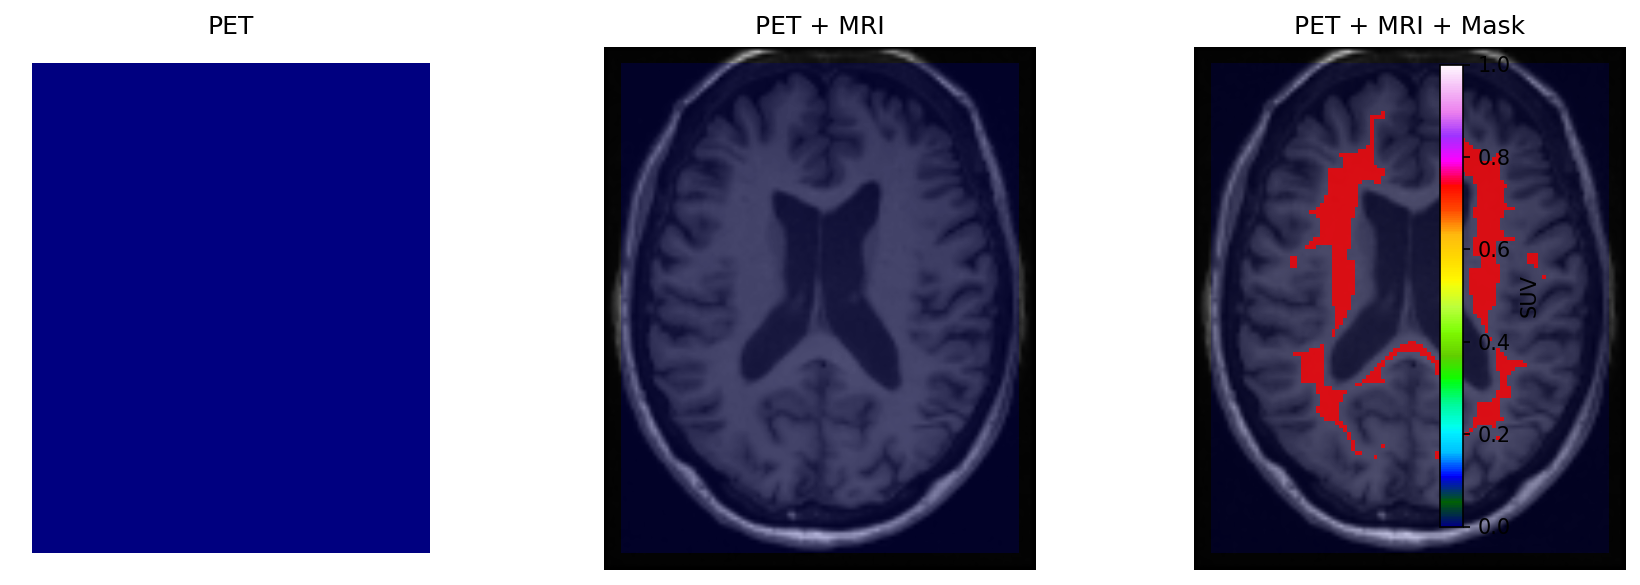

In [18]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Load images
pet = nib.load("shoot/HC/8007703562/20211104/wr_petsuv.nii")
pet_data = pet.get_fdata()

mri = nib.load("shoot/HC/8007703562/20211104/wmri.nii")
mri_data = mri.get_fdata()

mask = nib.load("shoot/HC/8007703562/20211104/mri/wm_mask_eroded.nii")
mask_data = mask.get_fdata()

# Choose slice
z = 62
pet_slice = np.rot90(pet_data[:, :, z])
mri_slice = np.rot90(mri_data[:, :, z])
mask_slice = np.rot90(mask_data[:, :, z])

# Mask: hide zeros
mask_overlay = np.ma.masked_where(mask_slice == 0, mask_slice)

# Optional: clean red colormap for mask
red_cmap = ListedColormap(['red'])

# Contrast (recommended)
vmax = np.percentile(pet_slice, 99)

# Create figure with 3 panels
fig, axes = plt.subplots(1, 3, figsize=(12, 4), dpi=150)

# --- 1. PET only ---
axes[0].imshow(
    pet_slice,
    cmap='gist_ncar',
    vmin=0,
    vmax=vmax,
    interpolation='lanczos'
)
axes[0].set_title("PET")
axes[0].axis('off')

# --- 2. PET + MRI ---
axes[1].imshow(mri_slice, cmap='gray', interpolation='bilinear')

axes[1].imshow(
    pet_slice,
    cmap='gist_ncar',
    vmin=0,
    vmax=vmax,
    alpha=0.3,
    interpolation='lanczos'
)
axes[1].set_title("PET + MRI")
axes[1].axis('off')

# --- 3. PET + MRI + Mask ---
axes[2].imshow(mri_slice, cmap='gray', interpolation='bilinear')

axes[2].imshow(
    pet_slice,
    cmap='gist_ncar',
    vmin=0,
    vmax=vmax,
    alpha=0.25,
    interpolation='lanczos'
)

axes[2].imshow(
    mask_overlay,
    cmap=red_cmap,
    alpha=0.8,
    interpolation='nearest'
)

axes[2].set_title("PET + MRI + Mask")
axes[2].axis('off')

# Shared colorbar (based on PET)
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap='gist_ncar'),
    ax=axes,
    fraction=0.02,
    pad=0.02
)
cbar.set_label("SUV")

plt.tight_layout()
plt.show()